In [1]:
import numpy as np
import bluepysnap as bp
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib ipympl

In [2]:
s = bp.Simulation('simulation_config.json')
c = s.circuit

In [3]:
nodes = c.nodes['S1nonbarrel_neurons']

In [4]:
locs = nodes.get('hex0',properties=['x','y','z'])

In [5]:
locs = locs.sample(1000)

In [6]:
locs

,x,y,z
node_ids,,,
159040,4580.095696,-1311.686757,-1961.044268
106613,3481.899850,-1159.449071,-3061.201694
12240,4319.523750,-1155.464101,-2069.602561
133252,4098.570596,-1222.444351,-2184.806753
178357,3984.895121,-1444.214542,-2569.637769
...,...,...,...
20498,4338.684150,-1192.372101,-1896.720798
204722,3807.731669,-1147.806892,-2386.864978
168513,4622.409834,-1407.096527,-2016.840364


In [7]:
electrodes = pd.read_csv('electrode_csv_highRes_lfpOnly_newAxis.csv')

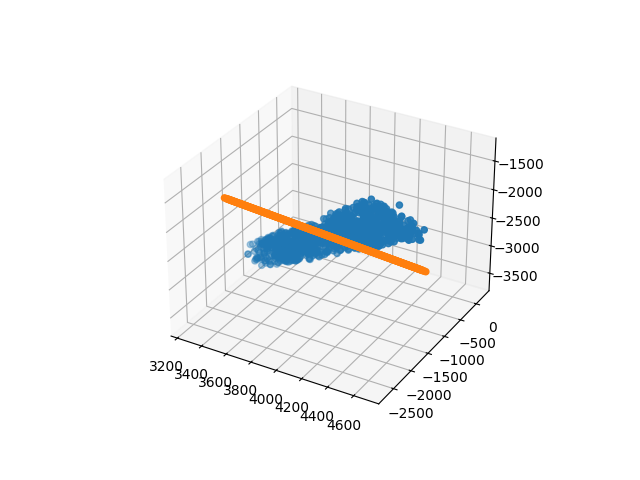

In [8]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(locs['x'],locs['y'],locs['z'])
ax.scatter(electrodes['x'],electrodes['y'],electrodes['z'],alpha=1)
plt.show()

In [9]:
from sklearn.decomposition import PCA

somaPos = nodes.get(properties=['x','y','z'],group='hex0') # Gets soma position

center = np.mean(somaPos,axis=0).values

pca = PCA(n_components=3)
pca.fit(somaPos)
main_axis = pca.components_[0]

newPositions = np.dot(somaPos,main_axis)
highest = newPositions.argsort()[-5000:]
lowest = newPositions.argsort()[:5000]




In [10]:
highestSoma = somaPos.iloc[highest]
highestCenter = np.mean(highestSoma,axis=0)

lowestSoma = somaPos.iloc[lowest]
lowestCenter = np.mean(lowestSoma,axis=0)

In [10]:
lowestCenter

x    3456.797071
y   -1124.321262
z   -3092.959325
dtype: float64

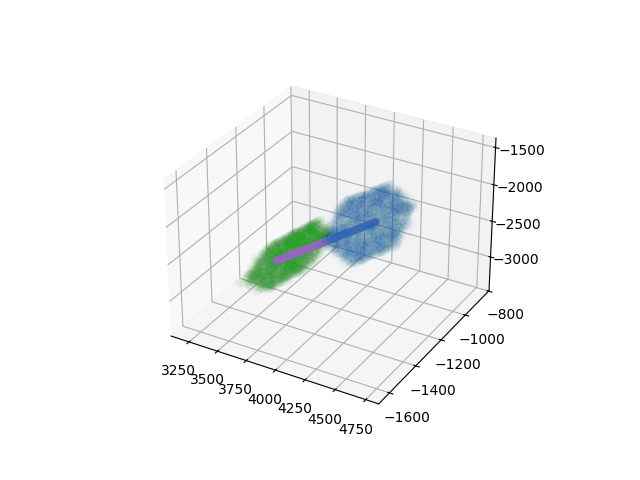

In [11]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(somaPos['x'].iloc[highest],somaPos['y'].iloc[highest],somaPos['z'].iloc[highest],alpha=0.01)
ax.scatter(highestCenter['x'],highestCenter['y'],highestCenter['z'])

ax.scatter(somaPos['x'].iloc[lowest],somaPos['y'].iloc[lowest],somaPos['z'].iloc[lowest],alpha=0.01)
ax.scatter(lowestCenter['x'],lowestCenter['y'],lowestCenter['z'])

ax.scatter(electrodes['x'],electrodes['y'],electrodes['z'],alpha=1)
ax.plot([lowestCenter['x'],highestCenter['x']],[lowestCenter['y'],highestCenter['y']],[lowestCenter['z'],highestCenter['z']])
plt.show()

In [19]:
lowestCenter-highestCenter

x    -962.445907
y     241.780277
z   -1253.364522
dtype: float64

In [ ]:
main_axis=np.mean(somaPos.iloc[highest],axis=0)-np.mean(somaPos.iloc[lowest],axis=0)

elevation = np.arctan2(main_axis[2], np.sqrt(main_axis[0]**2+main_axis[1]**2)) 
azimuth = np.arctan2(main_axis[1],main_axis[0])